In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías, del modelo final guardado por `04_model_training.ipynb` (`models/sevilla/price_model.pkl`, `models/sevilla/model_metadata.json`) y del test (`data/processed/sevilla/listings_test.csv`). Este notebook no reentrena nada, parte de lo que ya quedó guardado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load(f"{PROJECT_DIR}/models/sevilla/price_model.pkl")

with open(f"{PROJECT_DIR}/models/sevilla/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/sevilla/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 272.8176860844319,
 'MAE': 56.27719491749269,
 'R2': 0.16846761500945773,
 'MAPE': 26.852435058078957,
 'R2_log': 0.6000635498768778}

## 2. Reconstruir predicciones

Mismos `feature_cols`/`target` que en el entrenamiento (guardados en `metadata`), para tener `y_test` y las predicciones disponibles para todo el análisis que sigue.

### 2.1 X e y de test

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(1528, 71)

### 2.2 Función `evaluate`

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

El modelo predice en escala `log1p(price)`; se deshace con `expm1` antes de evaluar nada.

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(272.8176860844319),
 'MAE': 56.27719491749269,
 'R2': 0.16846761500945773,
 'MAPE': np.float64(26.852435058078957)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=272.82€, MAE=56.28€, R²=0.17, MAPE=26.85%): el modelo cargado predice igual que cuando se guardó, así que el análisis de errores parte de una base fiable.

## 3. Predicción vs. realidad

Scatter de precio predicho contra precio real, y distribución de los residuos (`predicho - real`). El objetivo es detectar sesgos sistemáticos que un único R² no muestra.

### 3.1 Predicho vs. real

(0.0, 1500.0)

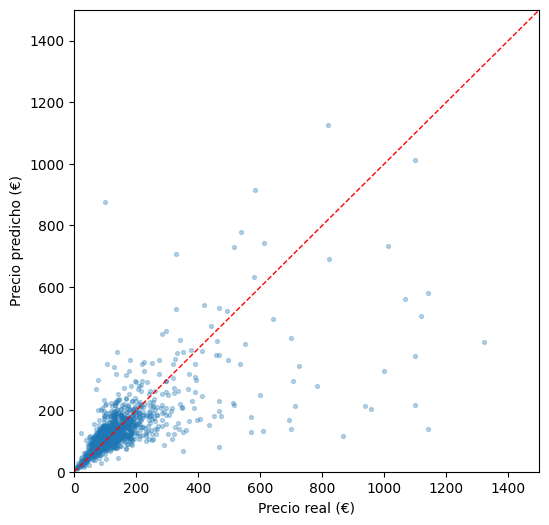

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 1500]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Para precios bajos y medios los puntos siguen razonablemente la diagonal. A partir de unos 300-400€, cada vez más puntos caen por debajo: **el modelo tiende a subestimar los anuncios más caros**, el mismo patrón que en las otras cuatro ciudades.

### 3.2 Distribución de los residuos

Media: -23.492294301344135
Mediana: 2.3514559284636434


(-500.0, 500.0)

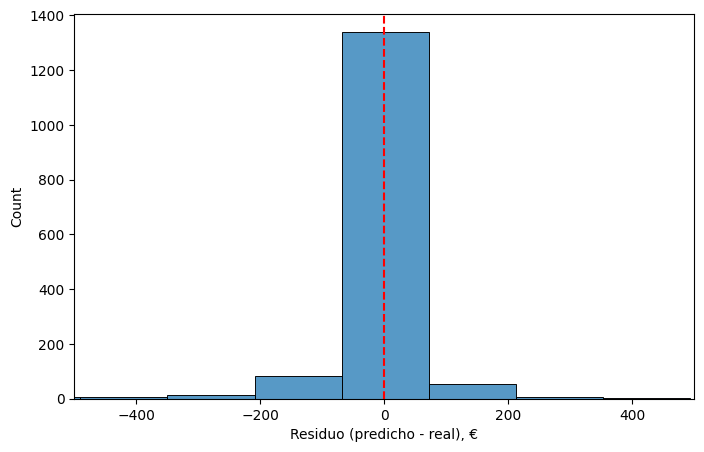

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)

La mediana del residuo es prácticamente 0 (+2.35€), pero la **media es -23.49€**, mucho más negativa — la brecha media/mediana más grande de las cinco ciudades: hay una cola de subestimaciones enormes en una sola dirección (los precios extremos ya vistos en la EDA/baseline) que arrastra la media con mucha más fuerza que en las otras ciudades, aunque la mitad de los anuncios se acierten casi exactos.

### 3.3 ¿El sesgo depende del precio?

(0.0, 1500.0)

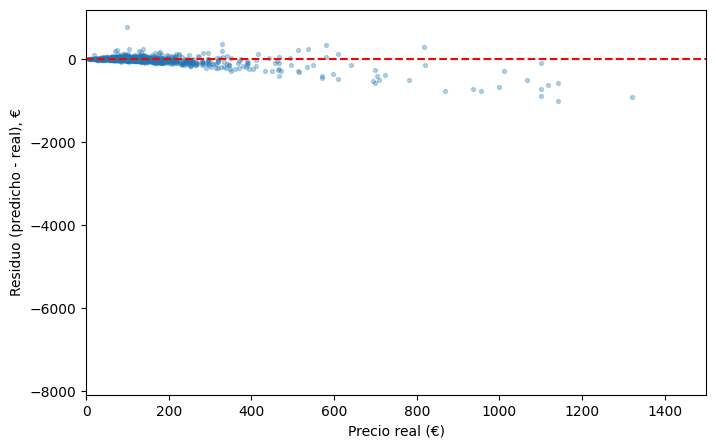

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 1500)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(4.779, 76.5]",15.874954,11.221229,308
"(76.5, 98.7]",16.850407,12.355183,303
"(98.7, 124.0]",7.959691,1.714082,313
"(124.0, 168.534]",-1.618877,-9.893542,298
"(168.534, 8052.0]",-156.537068,-51.933762,306


Confirmado con números, y con la asimetría más marcada de las cinco ciudades: en los tres quintiles más bajos el residuo medio es **positivo** (+15.9€, +16.9€, +8.0€, el modelo sobreestima los anuncios baratos), el cuarto quintil ya es ligeramente negativo (-1.6€), y en el quintil más caro (por encima de 168.5€) el residuo medio es **-156.5€** (mediana -51.9€) — una subestimación severa, muy por encima de la de las otras ciudades en términos relativos.

Misma explicación de fondo que en las otras ciudades: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta se traduce en un error absoluto grande al deshacer el logaritmo. Pero aquí el efecto es más extremo porque la propia cola alta lo es (sección 8.2 de `03_model_baseline.ipynb`): el sesgo hacia sobreestimar lo barato y subestimar lo caro es una limitación real del modelo, agravada por la decisión (correcta, dado que no había criterio objetivo) de no recortar esa cola en la EDA.

## 4. Errores por segmento

MAE/RMSE desglosados por `room_type`, por distrito y por rango de precio.

### 4.1 Por `room_type`

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,289.21,59.11,0.16,26.18,1333
Private room,108.87,37.13,0.44,31.15,187
Shared room,31.90,19.87,-1.94,46.96,5
Hotel room,66.52,52.02,0.36,24.96,3


`Entire home/apt` (1333 filas, la mayoría del test) tiene el RMSE más alto con diferencia (289.21€), esperable por ser la categoría que concentra toda la cola de precios extremos. `Private room` tiene errores mucho más bajos en RMSE (108.87€) y mejor R² (0.44, frente a 0.16 en `Entire home/apt`) pese a un MAPE algo más alto (31.15% frente a 26.18%): en términos absolutos se acierta mejor, en términos relativos un poco peor (habitaciones privadas más baratas, donde un mismo error en euros pesa más en porcentaje). `Shared room` (5 filas) y `Hotel room` (3 filas) tienen muestra demasiado pequeña para sacar ninguna conclusión — el R² negativo de `Shared room` (-1.94) es ruido de 5 filas, no una señal real.

### 4.2 Por distrito

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Casco Antiguo,214.49,53.71,0.23,26.08,1067
Triana,585.31,82.37,0.07,27.92,175
Nervión,154.01,52.22,0.47,24.08,99
Macarena,76.44,31.00,0.34,19.84,48
San Pablo - Santa Justa,44.74,30.23,0.59,26.16,35
Sur,150.42,79.05,0.62,26.15,27
Los Remedios,142.50,74.49,0.23,42.03,25
Cerro - Amate,26.07,17.45,0.80,21.25,19
Este - Alcosa - Torreblanca,45.74,31.26,0.75,24.52,12


Dos distritos destacan negativamente, y por motivos distintos. **`Triana`** (175 filas) tiene el RMSE más alto de todos (585.31€) y R²=0.07: se explica en la sección 5, donde 2 de los 15 peores errores del test caen ahí, incluido el peor de todos. **`Palmera - Bellavista`** (solo 10 filas) tiene un R² catastrófico (-3.77) y un MAPE altísimo (113.81%): con una muestra tan pequeña, un único error grande (también identificado en la sección 5, y esta vez una *sobre*estimación, no una subestimación) basta para destrozar la métrica del distrito entero. El resto se mueve en un rango de R² razonable (0.23-0.80), con `Cerro - Amate` (R²=0.80, 19 filas) como el mejor ajustado. Igual que en las otras ciudades, el tamaño de muestra por distrito no explica por sí solo el R²: importa más qué anuncios concretos caen en el test de cada zona.

### 4.3 Por rango de precio

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(4.779, 76.5]",28.90,18.70,-1.91,35.00,308
"(76.5, 98.7]",30.25,21.33,-22.44,24.41,303
"(98.7, 124.0]",53.02,22.20,-46.88,20.46,313
"(124.0, 168.534]",42.89,30.68,-11.10,21.76,298
"(168.534, 8052.0]",604.36,188.49,0.03,32.57,306


El MAE crece con fuerza en el quintil más caro (18.70€ → 21.33€ → 22.20€ → 30.68€ → 188.49€), mucho más pronunciado que en las otras ciudades. El R² por quintil sale negativo en los cuatro primeros tramos, por el mismo motivo que en las otras ciudades: al cortar por rangos de precio, la variabilidad *dentro* de cada quintil es pequeña por construcción, y ahí el R² deja de ser una métrica útil — solo el quintil más caro (con más margen de variabilidad real, y donde caen los precios extremos) da un R² positivo (0.03, aun así muy bajo). Para segmentar por precio conviene mirar MAE/RMSE en euros, no R².

## 5. Los peores casos

Los anuncios con mayor error absoluto, inspeccionados uno a uno.

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["room_type"] = room_type_series.iloc[worst_idx].values
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,room_type,pred,residual
501,1336105073765771875,8052.00,3.0,6,1.0,1.5,Entire home/apt,390.004000,-7661.996000
7,1538935225501429692,3702.61,2.0,3,60.0,1.0,Entire home/apt,39.140529,-3663.469471
463,4293362,3490.00,1.0,4,1.0,1.0,Entire home/apt,383.201650,-3106.798350
1445,33825567,3000.00,1.0,4,1.0,1.0,Entire home/apt,142.949793,-2857.050207
794,835168629119597919,2187.67,3.0,4,20.0,1.0,Entire home/apt,78.450152,-2109.219848
654,558331235824401686,3510.00,3.0,8,1.0,2.0,Entire home/apt,1451.497644,-2058.502356
813,45429059,1521.00,2.0,6,2.0,1.0,Entire home/apt,260.241522,-1260.758478
1186,913491360348023784,1142.00,2.0,4,1.0,1.5,Entire home/apt,139.935774,-1002.064226
523,16410261,1320.50,3.0,6,2.0,3.5,Entire home/apt,419.872781,-900.627219
71,1100553698362075369,1100.00,1.0,4,1.0,0.0,Private room,216.612743,-883.387257


### 5.2 Dos patrones dominantes, y un caso inverso

A diferencia de Barcelona (dominado por Group Flats) y de Valencia (repartido en tres grupos comparables), aquí un solo patrón concentra la mayoría de los peores errores. 14 de las 15 son subestimaciones; solo 1 es una sobreestimación.

In [14]:
cols_extra = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
extra = test_df.iloc[worst_idx][cols_extra].copy()
extra["district"] = district_series.iloc[worst_idx].values
extra

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews,district
501,1336105073765771875,8052.00,3.0,6,1.5,1.0,True,False,NaN,0,Triana
7,1538935225501429692,3702.61,2.0,3,1.0,60.0,True,False,NaN,0,Casco Antiguo
463,4293362,3490.00,1.0,4,1.0,1.0,True,False,4.83,46,Casco Antiguo
1445,33825567,3000.00,1.0,4,1.0,1.0,True,True,4.40,5,Casco Antiguo
794,835168629119597919,2187.67,3.0,4,1.0,20.0,True,False,4.83,18,Casco Antiguo
654,558331235824401686,3510.00,3.0,8,2.0,1.0,True,False,4.29,7,Casco Antiguo
813,45429059,1521.00,2.0,6,1.0,2.0,True,False,4.50,14,Nervión
1186,913491360348023784,1142.00,2.0,4,1.5,1.0,True,True,4.93,103,Casco Antiguo
523,16410261,1320.50,3.0,6,3.5,2.0,True,True,4.85,41,Casco Antiguo
71,1100553698362075369,1100.00,1.0,4,0.0,1.0,True,False,NaN,0,Casco Antiguo


**Grupo 1 — anuncios sin reviews, precio disuasorio** (4 de 15): `number_of_reviews=0` en los cuatro, tamaño modesto (`accommodates` 3-6), precios de 1100-8052€. El propio "Rent it if you can afford it!" de la EDA (sección 8.2) es el peor error de todo el test, por un margen enorme (-7662€). Es exactamente el patrón que la EDA identificó pero decidió no poder aislar con un criterio objetivo — y aquí se ve el coste real de esa decisión.

**Grupo 2 — anuncios populares y bien valorados, con un precio puntual disparado** (9 de 15, el grupo más numeroso, con diferencia): tamaño modesto (`bedrooms` 1-3, `accommodates` 2-6) pero con **reviews reales y en su mayoría muy buenas** — hasta 103 reseñas con nota 4.93, o 46 reseñas con nota 4.83. No son anuncios fantasma: son alojamientos activos y valorados con un precio concreto muy por encima de lo que su tamaño explica. Es el mismo hallazgo que en Valencia (donde era un grupo minoritario), pero aquí es, con diferencia, el patrón más frecuente entre los peores errores.

**Un caso aparte — un piso genuino para grupos grandes** (1 de 15): `accommodates=8`, 3 dormitorios, 3510€, con reviews reales (7 reseñas, nota 4.29). El único de los 15 que se parece al patrón "Group Flat" de Barcelona: tamaño real, no un artefacto de precio.

**El único caso inverso — sobreestimación por un descuento de larga estancia** (1 de 15): una casa grande genuina (5 dormitorios, `accommodates=8`, 4 baños) con `minimum_nights=61` y sin licencia ni reviews, a solo **99.81€/noche** — el modelo predice 874.69€ guiándose por el tamaño, sin anticipar del todo el descuento tan fuerte que implica una estancia mínima de dos meses. Es justo el distrito (`Palmera - Bellavista`) que salió con R² catastrófico en la sección 4.2.

En conjunto, el patrón dominante en Sevilla (9-10 de 15 casos) es distinto al de Barcelona (Group Flats) y más extremo que el de Valencia: anuncios reales, activos y bien valorados, con un precio puntual que no guarda relación con su tamaño ni con el resto del mercado. Ninguno de los cuatro grupos se soluciona con más ajuste de hiperparámetros: haría falta una detección de precios no realistas más general que el filtro por valor exacto usado en la EDA — algo como marcar anuncios cuyo precio se aparta mucho de la mediana de anuncios similares (mismo barrio/tamaño), independientemente de si ese valor se repite en otras filas o no.

## 6. Nota sobre la fuga de `neighbourhood_price_encoded` (ya corregida)

Igual que en las otras cuatro ciudades: `02_feature_engineering.ipynb` mantiene `neighbourhood_cleansed` hasta después del split, y `03_model_baseline.ipynb` recalcula el encoding usando solo train (sección 3.1bis) antes de guardar `listings_train.csv`/`listings_test.csv` — con la particularidad, única de Sevilla, de que 3 barrios de test no aparecían en train y recibieron la media global como respaldo (también en la sección 3.1bis). El modelo cargado al principio de este notebook ya viene entrenado con la versión corregida — `metadata["test_metrics"]` de la sección 1 son los números honestos, no hay ninguna fuga pendiente que investigar aquí.

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó. En conjunto, **es el modelo más limitado de las cinco ciudades** (R²=0.17, muy por debajo del resto), con una causa de fondo ya identificada desde `01_eda.ipynb`: una cola de precios extremos sin criterio objetivo de artefacto que aislar. No arrastra la fuga de `neighbourhood_price_encoded` ni el riesgo de un split no representativo por `room_type` (ambos corregidos en `02_feature_engineering.ipynb`/`03_model_baseline.ipynb`), así que las métricas son honestas de principio a fin — son bajas porque el problema es genuinamente más difícil aquí, no por un error de pipeline.

### Lo que funciona bien

- Sesgo moderado en los cuatro quintiles de precio más bajos (entre -1.6€ y +16.9€ de media), sin el colapso que sí se ve en el quintil más caro.
- `Private room` (R²=0.44, RMSE=108.87€) se predice bastante mejor que `Entire home/apt`.
- La mediana del residuo es prácticamente cero (+2.35€): la mitad de las predicciones son muy precisas, el problema se concentra en una cola de casos identificables, no en un sesgo generalizado.

### Limitaciones identificadas

1. **Subestima con fuerza los anuncios más caros**: residuo medio de -156.5€ en el quintil superior de precio (frente a un rango de +8€ a +16.9€ en los tres quintiles más baratos) — el sesgo más pronunciado de las cinco ciudades.
2. **Dos distritos con métricas anómalas por razones opuestas**: `Triana` (R²=0.07) por una concentración de subestimaciones grandes, `Palmera - Bellavista` (R²=-3.77, solo 10 filas) por un único error de sobreestimación — ninguno de los dos es un problema sistemático de la zona en sí.
3. **Un patrón dominante detrás de los peores errores, más pronunciado que en cualquier otra ciudad**: 9 de los 15 peores casos son anuncios reales, activos y bien valorados con un precio puntual desproporcionado a su tamaño — el mismo fenómeno que en Valencia, pero aquí es la norma entre los peores errores, no la excepción.
4. **Un caso de sobreestimación por descuento de larga estancia** (`minimum_nights=61`): el modelo no captura del todo la magnitud del descuento en casas grandes con estancias mínimas muy largas.

### Recomendaciones

**De cara a un producto real**: dar un **rango de precio, no un número único**, y avisar explícitamente en los casos de baja confianza — aquí con más motivo que en las otras ciudades: anuncios con muy pocas reviews (sección 5.2, Grupo 1) y, sobre todo, cualquier anuncio en el tramo alto de precio, donde el error esperado es varias veces mayor que en el resto del mercado.

**De cara a mejorar el modelo, no aplicado aquí**:
- Tratar la cola alta de precio de forma distinta (modelo separado o pesos distintos en el entrenamiento), con más motivo en Sevilla que en ninguna otra ciudad dado lo que se vio en `03_model_baseline.ipynb`.
- Ampliar la detección de precios no realistas más allá del filtro por valor exacto usado en la EDA: marcar anuncios cuyo precio se aparta mucho de la mediana de anuncios similares (mismo barrio/tamaño), para capturar el Grupo 2 de la sección 5.2, que aquí es el patrón dominante.
- Revisar si `minimum_nights` muy altos (60+ noches) necesitan un tratamiento específico, dado el caso de sobreestimación de la sección 5.2.